# M13 · ANN / Vector Search & Indexing — Hands-on, Step by Tiny Step

**Companion to lesson M13. Written for someone new to ML.**

M12 gave us embeddings to search. But **exact** search — compare the query to *every* vector —
is too slow at millions of items. **Approximate Nearest Neighbor (ANN)** indexes skip most of
the work: search a **graph**, probe a few **partitions**, or store **compressed** vectors. The
catch: ANN isn't free speed — it **trades recall for latency and memory**. This notebook builds
tiny working versions of the three big index families and shows how to tune the tradeoff.

**What you'll do (every step has an explanation, logging, and a picture):**
- **Part A · The methods:** see why **exact kNN** doesn't scale, then build toy **IVF**
  (partition + probe), **PQ** (compression), and **HNSW** (graph walk) — each with its
  **recall knob**.
- **Part B · Tuning:** sweep the **recall-vs-latency frontier** to an **operating point**, and
  add **hybrid dense + lexical** retrieval for exact-name queries.

We use **scikit-learn** + **matplotlib** (no installs in Colab). Run each cell with
**Shift+Enter**.

## Step 1 · Setup + a shared corpus

We build **one** synthetic embedding corpus (clustered, like real embeddings) and a query set,
and reuse them for every index so comparisons are fair. **Exact** brute-force top-k is our
**ground-truth baseline** for measuring recall.

In [2]:
import numpy as np, pandas as pd, time, heapq
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#888"

rng = np.random.default_rng(0)
N, DIM = 6000, 32
lab = rng.integers(0, 30, N)
centers = rng.normal(0, 1, (30, DIM))
X = (centers[lab] + rng.normal(0, 0.4, (N, DIM))).astype(np.float32)     # the corpus
Q = (X[rng.choice(N, 300, replace=False)] + rng.normal(0, 0.2, (300, DIM))).astype(np.float32)

def exact_topk(q, k=20): return set(np.argsort(-(X @ q))[:k])            # ground truth
def recall_of(fn, k=20):                                                # avg over queries
    return float(np.mean([len(exact_topk(q, k) & fn(q, k)) / k for q in Q]))
print(f"corpus: {N} vectors x {DIM} dims,  {len(Q)} test queries")

corpus: 6000 vectors x 32 dims,  300 test queries


---
# Part A · The three index families

## Step 2 · Why exact kNN doesn't scale

Exact search computes a score for **every** vector, so latency grows **linearly** with corpus
size. Fine for an offline baseline; too slow for a live endpoint at millions of items.

**recall@k** is how we grade an approximate index against exact:
$$\text{recall@}k=\frac{|\text{approx top-}k \cap \text{exact top-}k|}{k}$$

In [5]:
print("exact-scan latency grows with corpus size:")
for n in [10000, 50000, 200000]:
    Xn = rng.normal(0, 1, (n, 64)).astype(np.float32); qn = rng.normal(0, 1, 64).astype(np.float32)
    t = time.perf_counter(); [np.argsort(-(Xn @ qn))[:10] for _ in range(20)]; dt = (time.perf_counter()-t)/20
    print(f"  {n:>7} vectors: {dt*1000:6.1f} ms/query")
print("\n-> at millions of vectors this blows the latency budget. ANN searches a FRACTION instead.")

exact-scan latency grows with corpus size:
    10000 vectors:    2.7 ms/query
    50000 vectors:    6.6 ms/query
   200000 vectors:   20.8 ms/query

-> at millions of vectors this blows the latency budget. ANN searches a FRACTION instead.


## Step 3 · IVF — partition & probe (the partition family)

**Inverted File** index: cluster the corpus into `nlist` cells; at query time probe only the
**nearest `nprobe` cells** and score just those. The knob `nprobe` trades recall for how much
of the corpus you scan. (Same idea as M12's serving index.)

In [7]:
nlist = 64
km = KMeans(nlist, n_init=3, random_state=0).fit(X)
cents = km.cluster_centers_; members = [np.where(km.labels_ == c)[0] for c in range(nlist)]

def ivf(q, k=20, nprobe=8):
    near = np.argsort(-(cents @ q))[:nprobe]
    cand = np.concatenate([members[c] for c in near])
    if len(cand) < k: return set(cand)
    return set(cand[np.argsort(-(X[cand] @ q))[:k]])

print(f"IVF: {N} vectors in {nlist} cells")
print(f"{'nprobe':>7}{'recall@20':>11}{'% scanned':>11}")
ivf_rows = []
for nprobe in [1, 2, 4, 8, 16, 32]:
    rec = recall_of(lambda q, k: ivf(q, k, nprobe))
    scanned = np.mean([sum(len(members[c]) for c in np.argsort(-(cents@q))[:nprobe]) for q in Q]) / N
    ivf_rows.append((nprobe, rec, scanned*100)); print(f"{nprobe:>7}{rec:>11.2f}{scanned*100:>10.1f}%")

IVF: 6000 vectors in 64 cells
 nprobe  recall@20  % scanned
      1       0.64       1.7%
      2       0.94       3.2%
      4       1.00       6.1%
      8       1.00      12.2%
     16       1.00      24.3%
     32       1.00      49.0%


## Step 4 · PQ — compress the vectors (the quantization family)

**Product Quantization** shrinks memory: split each vector into `m` subvectors, and replace
each subvector with the **id of its nearest centroid** from a small codebook. A 32-float
vector (128 bytes) becomes `m` bytes. Huge memory savings — at the cost of **quantization
error** (approximate scores → lower recall).

PQ compression:
  full vectors: 768 KB   ->   PQ codes: 48 KB   (16x smaller)
  recall@20:  full-precision 1.00   PQ-compressed 0.59  (memory saved, recall dips)


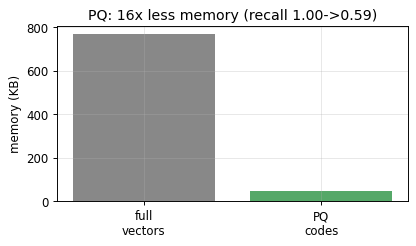

In [9]:
m, ksub = 8, 256; sub = DIM // m                       # 8 subvectors, 256 centroids each -> 1 byte/subvector
codebooks, codes = [], np.zeros((N, m), dtype=np.uint8)
for s in range(m):
    part = X[:, s*sub:(s+1)*sub]
    kms = KMeans(ksub, n_init=2, random_state=0).fit(part)
    codebooks.append(kms.cluster_centers_.astype(np.float32)); codes[:, s] = kms.labels_
Xpq = np.concatenate([codebooks[s][codes[:, s]] for s in range(m)], axis=1)   # approx reconstruction

full_bytes = X.nbytes; code_bytes = codes.nbytes
print("PQ compression:")
print(f"  full vectors: {full_bytes/1e3:.0f} KB   ->   PQ codes: {code_bytes/1e3:.0f} KB   ({full_bytes/code_bytes:.0f}x smaller)")
rec_pq = recall_of(lambda q, k: set(np.argsort(-(Xpq @ q))[:k]))
rec_exact_mem = recall_of(lambda q, k: exact_topk(q, k))
print(f"  recall@20:  full-precision {rec_exact_mem:.2f}   PQ-compressed {rec_pq:.2f}  (memory saved, recall dips)")
plt.figure(figsize=(5,3))
plt.bar(["full\nvectors","PQ\ncodes"], [full_bytes/1e3, code_bytes/1e3], color=[GRAY, GREEN])
plt.ylabel("memory (KB)"); plt.title(f"PQ: {full_bytes/code_bytes:.0f}x less memory (recall {rec_exact_mem:.2f}->{rec_pq:.2f})"); plt.show()

## Step 5 · HNSW — walk a graph (the graph family)

**Hierarchical Navigable Small World** links each vector to nearby vectors, then **greedily
walks** the graph toward the query, exploring a candidate set of size `efSearch`. We build a
neighbor graph (plus a few long-range links — HNSW's upper-layer shortcuts) and run the real
greedy search. Knob `efSearch` trades recall for nodes visited (latency).

In [11]:
knn = NearestNeighbors(n_neighbors=16).fit(X); _, nn_graph = knn.kneighbors(X)
graph = np.concatenate([nn_graph, rng.integers(0, N, (N, 4))], axis=1)      # + long-range links

def hnsw(q, k=20, efSearch=40):
    dist = lambda i: -float(X[i] @ q)                  # smaller = closer
    entry = rng.integers(0, N); d0 = dist(entry)
    cand = [(d0, entry)]; res = [(-d0, entry)]; seen = {entry}; visited = 1
    while cand:
        cd, c = heapq.heappop(cand)
        if cd > -res[0][0]: break                      # closest candidate worse than worst kept -> stop
        for e in graph[c]:
            if e in seen: continue
            seen.add(e); visited += 1; de = dist(e)
            if de < -res[0][0] or len(res) < efSearch:
                heapq.heappush(cand, (de, e)); heapq.heappush(res, (-de, e))
                if len(res) > efSearch: heapq.heappop(res)
    top = [e for _, e in heapq.nlargest(k, res)]       # res holds (dot, e) -> nlargest = nearest
    return set(top), visited

print(f"{'efSearch':>9}{'recall@20':>11}{'nodes visited':>15}  (of {N})")
hnsw_rows = []
for ef in [10, 20, 40, 80, 160]:
    recs = [len(exact_topk(q,20) & hnsw(q,20,ef)[0])/20 for q in Q]
    vis  = [hnsw(q,20,ef)[1] for q in Q]
    hnsw_rows.append((ef, np.mean(recs), np.mean(vis)))
    print(f"{ef:>9}{np.mean(recs):>11.2f}{np.mean(vis):>15.0f}")

 efSearch  recall@20  nodes visited  (of 6000)
       10       0.41            215
       20       0.70            300
       40       0.84            412
       80       0.91            581
      160       0.94            883


## Step 6 · The three families side by side

Same corpus, three ways to skip work:
- **IVF** — probe a few **partitions** (knob `nprobe`); intuitive, scalable.
- **PQ** — store **compressed codes**; tiny memory, some recall loss.
- **HNSW** — **walk a graph** (knob `efSearch`); high recall, memory-heavy.

Each raises recall by doing more work. Real systems often **combine** them (e.g. IVF-PQ, or
ScaNN = partition + quantize + rerank).

         family      knob            saves                  watch out
IVF (partition)    nprobe  scans few cells      misses unprobed cells
  PQ (compress) code size      less memory quantization lowers recall
   HNSW (graph)  efSearch visits few nodes         memory-heavy graph


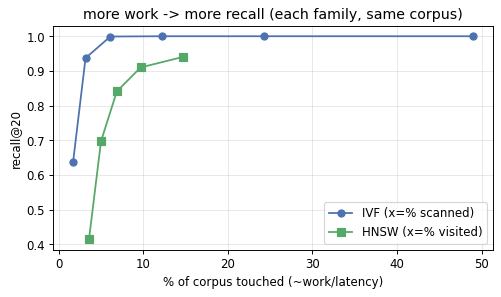

In [13]:
summary = pd.DataFrame({
    "family": ["IVF (partition)", "PQ (compress)", "HNSW (graph)"],
    "knob":   ["nprobe", "code size", "efSearch"],
    "saves":  ["scans few cells", "less memory", "visits few nodes"],
    "watch out": ["misses unprobed cells", "quantization lowers recall", "memory-heavy graph"],
})
print(summary.to_string(index=False))
plt.figure(figsize=(6,3.6))
plt.plot([r[2] for r in ivf_rows], [r[1] for r in ivf_rows], "o-", color=BLUE, label="IVF (x=% scanned)")
plt.plot([r[2]/N*100 for r in hnsw_rows], [r[1] for r in hnsw_rows], "s-", color=GREEN, label="HNSW (x=% visited)")
plt.xlabel("% of corpus touched (~work/latency)"); plt.ylabel("recall@20"); plt.legend()
plt.title("more work -> more recall (each family, same corpus)"); plt.show()

---
# Part B · Tuning the tradeoff + hybrid retrieval

## Step 7 · Knob sweep → tradeoff curve → operating point

The right question isn't "which index is best?" — it's "which setting is the **cheapest** one
that meets the product's **recall bar** and **latency budget**?" Plot recall vs work; good
settings sit on the **frontier** (nothing beats them on both axes). Pick the cheapest point
above the bar.

cheapest IVF setting meeting recall>=0.9: nprobe=2  (0.94 recall, 3.2% scanned)


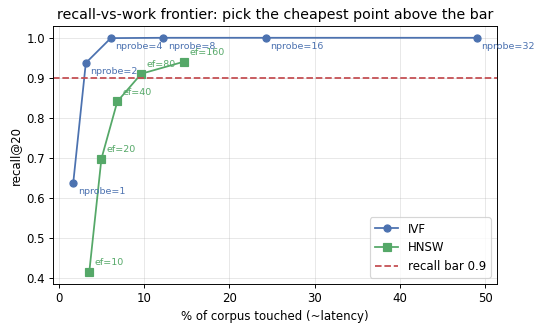

In [16]:
bar = 0.90
plt.figure(figsize=(6.5,4))
plt.plot([r[2] for r in ivf_rows], [r[1] for r in ivf_rows], "o-", color=BLUE, label="IVF")
for np_, rc, sc in ivf_rows: plt.annotate(f"nprobe={np_}", (sc, rc), textcoords="offset points", xytext=(4,-9), fontsize=8, color=BLUE)
plt.plot([r[2]/N*100 for r in hnsw_rows], [r[1] for r in hnsw_rows], "s-", color=GREEN, label="HNSW")
for ef, rc, vi in hnsw_rows: plt.annotate(f"ef={ef}", (vi/N*100, rc), textcoords="offset points", xytext=(4,6), fontsize=8, color=GREEN)
plt.axhline(bar, color=RED, ls="--", label=f"recall bar {bar}")
plt.xlabel("% of corpus touched (~latency)"); plt.ylabel("recall@20"); plt.legend()
plt.title("recall-vs-work frontier: pick the cheapest point above the bar"); plt.show()

ivf_ok = [r for r in ivf_rows if r[1] >= bar]
if ivf_ok:
    best = min(ivf_ok, key=lambda r: r[2])
    print(f"cheapest IVF setting meeting recall>={bar}: nprobe={best[0]}  ({best[1]:.2f} recall, {best[2]:.1f}% scanned)")

## Step 8 · Hybrid dense + lexical retrieval

Dense vectors are great for **semantic** matches ("brand-safe fitness creators"), but they can
**lose exact names / rare tokens** — a query for "Dr. Lina Chen robotics creator" may drown
among semantically-similar AI creators. **Term/lexical** retrieval (BM25) nails exact tokens.
**Hybrid** runs both and fuses: `score = α·dense + (1−α)·lexical`.

on 150 exact-name queries:
  dense-only recall@20 : 0.81   (target lost among similar-topic creators)
  hybrid     recall@20 : 1.00   (lexical exact-token match recovers it)


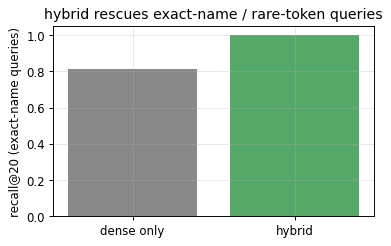

In [18]:
# 150 'exact-name' queries: find ONE specific creator sitting in a crowded topic
targets = rng.choice(N, 150, replace=False)
def dense_topk(qv, k=20): return list(np.argsort(-(X @ qv))[:k])
def lexical_match(name_id):  return [name_id]           # BM25 on a rare exact token -> that creator

dense_hit = hybrid_hit = 0
for t in targets:
    qv = X[t] + rng.normal(0, 0.3, DIM)                 # query lands in the target's crowded topic
    dtop = dense_topk(qv, 20)
    dense_hit  += int(t in dtop)
    hybrid_hit += int(t in set(dtop) | set(lexical_match(t)))   # union dense + exact lexical hit
print("on 150 exact-name queries:")
print(f"  dense-only recall@20 : {dense_hit/len(targets):.2f}   (target lost among similar-topic creators)")
print(f"  hybrid     recall@20 : {hybrid_hit/len(targets):.2f}   (lexical exact-token match recovers it)")
plt.figure(figsize=(4.6,3)); plt.bar(["dense only","hybrid"], [dense_hit/len(targets), hybrid_hit/len(targets)], color=[GRAY, GREEN])
plt.ylabel("recall@20 (exact-name queries)"); plt.title("hybrid rescues exact-name / rare-token queries"); plt.show()

---
## Recap — the M13 toolkit

**Why ANN (Part A).** Exact kNN scores every vector, so latency grows with corpus size. ANN
searches a **fraction** and accepts some **recall loss**. Three families:
- **IVF** — cluster into cells, probe the nearest `nprobe` (scans a fraction).
- **PQ** — store **compressed codes** (huge memory savings, quantization lowers recall).
- **HNSW** — **greedy-walk a neighbor graph** with breadth `efSearch` (high recall, more memory).
Real systems combine them (**IVF-PQ**, **ScaNN** = partition + quantize + rerank).

**Tuning (Part B).** Don't ask "best index?" — **sweep the knob, plot recall vs latency/memory,
pick the cheapest point on the frontier that meets the product bar.** Add **hybrid dense +
lexical** retrieval when exact names, rare tokens, or keyword filters matter — dense alone
loses them.

**The checklist:** measure against an **exact baseline**; sweep `nprobe` / `efSearch` /
compression together; plot **recall vs p95 latency & memory**; validate **slices** (rare
verticals, languages, cold-start); check **freshness** (index rebuild lag); decide whether the
bottleneck is index recall, candidate count, filters, or the reranker.

**Where this connects:** M13 is the index behind M12's retrieval funnel. The vectors it
searches are M11's embeddings, trained as **contrastive encoders** — the subject of **M14**.